## ERA5


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:
dataera5 = pd.read_csv("C:\Data analyst, scient, ML\data_scienct\prediksi hujan pasuruan\dowload_dataset\data_merge\era5_pasuruan_2016-2025_merged.csv")

In [4]:
dataera5

,datetime,latitude,longitude,tp,t2m,d2m,u10,v10
0,2016-01-01 00:00:00,-8.1,112.5,0.003074,297.59668,295.57446,-0.440109,0.633028
1,2016-01-01 00:00:00,-8.1,112.6,0.003453,298.23926,296.21118,-0.356613,0.687716
2,2016-01-01 00:00:00,-8.1,112.7,0.003868,298.30176,296.26000,-0.234543,0.770723
3,2016-01-01 00:00:00,-8.1,112.8,0.004375,295.53613,293.47680,-0.135910,0.847383
4,2016-01-01 00:00:00,-8.1,112.9,0.005261,293.10060,291.16820,-0.149582,0.888887
...,...,...,...,...,...,...,...,...
818267,2025-12-31 18:00:00,-7.5,112.8,NaN,NaN,NaN,NaN,NaN
818268,2025-12-31 18:00:00,-7.5,112.9,NaN,NaN,NaN,NaN,NaN
818269,2025-12-31 18:00:00,-7.5,113.0,NaN,NaN,NaN,NaN,NaN
818270,2025-12-31 18:00:00,-7.5,113.1,NaN,NaN,NaN,NaN,NaN


In [5]:
dataera5.isnull().sum()

datetime          0
latitude          0
longitude         0
tp           146120
t2m          146120
d2m          146120
u10          146120
v10          146120
dtype: int64

In [15]:
dataera5.columns

Index(['datetime', 'latitude', 'longitude', 'tp', 't2m', 'd2m', 'u10', 'v10'], dtype='object')

In [8]:
nan_rows = dataera5[
    dataera5[['tp', 't2m', 'd2m', 'u10', 'v10']]
    .isna()
    .any(axis=1)
]

nan_rows[['datetime']]

,datetime
38,2016-01-01 00:00:00
39,2016-01-01 00:00:00
45,2016-01-01 00:00:00
46,2016-01-01 00:00:00
47,2016-01-01 00:00:00
...,...
818267,2025-12-31 18:00:00
818268,2025-12-31 18:00:00
818269,2025-12-31 18:00:00
818270,2025-12-31 18:00:00


In [9]:
info_dataera5 = dataera5.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 818272 entries, 0 to 818271
Data columns (total 8 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   datetime   818272 non-null  object 
 1   latitude   818272 non-null  float64
 2   longitude  818272 non-null  float64
 3   tp         672152 non-null  float64
 4   t2m        672152 non-null  float64
 5   d2m        672152 non-null  float64
 6   u10        672152 non-null  float64
 7   v10        672152 non-null  float64
dtypes: float64(7), object(1)
memory usage: 49.9+ MB


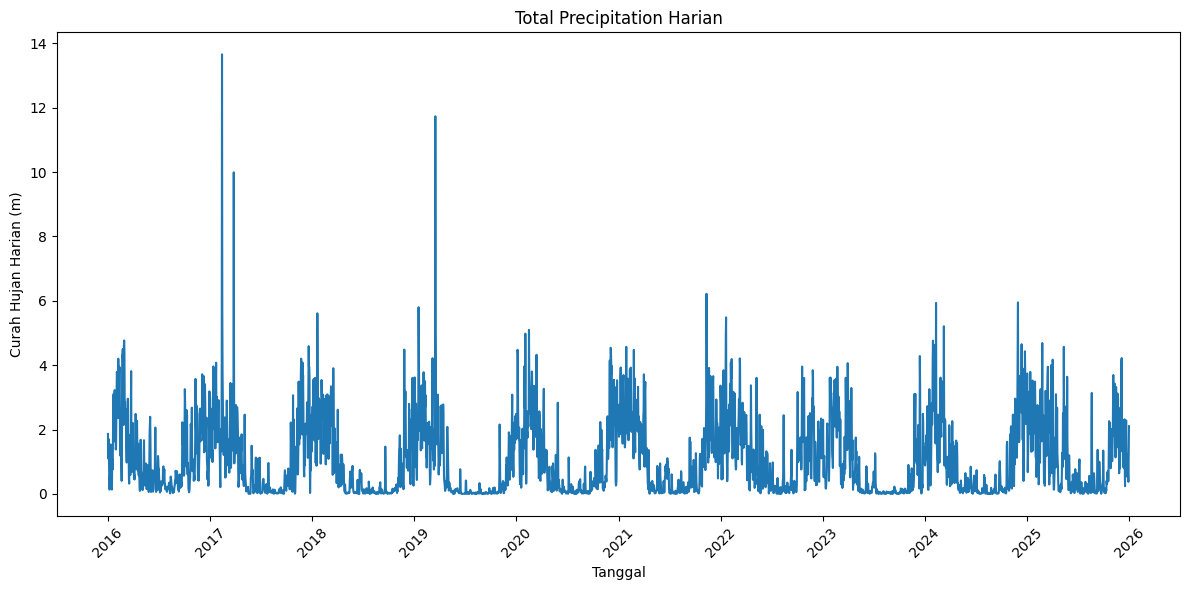

In [13]:
dataera5['datetime'] = pd.to_datetime(dataera5['datetime'])

tp_harian = (
    dataera5
    .set_index('datetime')
    .resample('D')['tp']
    .sum()
)

plt.figure(figsize=(12,6))
plt.plot(tp_harian.index, tp_harian.values)

plt.xlabel('Tanggal')
plt.ylabel('Curah Hujan Harian (m)')
plt.title('Total Precipitation Harian')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [16]:
dataera5['d2m'].isna().sum()

np.int64(146120)

In [17]:
dataera5['d2m'].describe()

count    672152.000000
mean        293.157028
std           3.043057
min         275.990230
25%         291.187740
50%         293.600100
75%         295.528560
max         300.645260
Name: d2m, dtype: float64